In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error
)

In [10]:
df=pd.read_csv("CIRC_model_ready.csv")
print(df.shape)
df.isnull().sum()
df.head()

(1141, 14)


,D,t,Fy,fc,L,Dt,LD,Ac,As,SteelCap,ConcCap,Squash,Xi,Pexp
0,94.996,12.4968,274.618291,27.365302,1420.114,7.601626,14.949198,3848.714899,3238.906636,889.463004,105.321247,994.784252,8.445238,947.026382
1,94.996,12.7508,272.618810,27.365302,1420.114,7.450199,14.949198,3793.058149,3294.563385,898.159951,103.798183,1001.958134,8.652945,937.685116
2,94.996,12.3952,272.618810,27.365302,1420.114,7.663934,14.949198,3871.091101,3216.530433,876.886700,105.933579,982.820279,8.277703,906.992387
3,94.996,12.5984,274.618291,27.365302,860.044,7.540323,9.053476,3826.403555,3261.217979,895.590107,104.710691,1000.300798,8.552996,1017.753106
4,94.996,12.7000,272.618810,27.365302,860.044,7.480000,9.053476,3804.157070,3283.464465,895.134176,104.101909,999.236085,8.598634,1007.967018


### Transforming Data

In [11]:
x=df.drop("Pexp",axis=1)
y=df["Pexp"]

In [12]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

### Data Preprocessing

In [13]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

### 2nd Best Model

                    Model  R2 Score   RMSE     MAE  MAPE (%)
XGBoost (L2) Testing Data    0.9788 586.57 217.286     14.36
                     Model  R2 Score    RMSE    MAE  MAPE (%)
XGBoost (L2) Training Data    0.9989 170.384 89.425      9.39


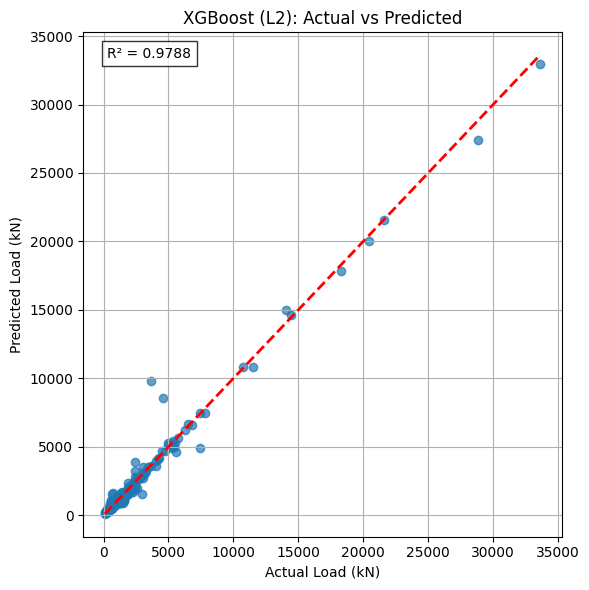

In [15]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(x_train_scaled, y_train)

# Prediction
y_xgb_train = xgb_model.predict(x_train_scaled)
y_xgb_pred = xgb_model.predict(x_test_scaled)

# Evaluation
xgb_results = pd.DataFrame({
    "Model": ["XGBoost (L2) Testing Data"],
    "R2 Score": [round(r2_score(y_test, y_xgb_pred),4)],
    "RMSE": [round(root_mean_squared_error(y_test, y_xgb_pred),3)],
    "MAE": [round(mean_absolute_error(y_test, y_xgb_pred),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_test, y_xgb_pred)*100,2)]
})
print(xgb_results.to_string(index=False))

xgb_res_train = pd.DataFrame({
    "Model": ["XGBoost (L2) Training Data"],
    "R2 Score": [round(r2_score(y_train, y_xgb_train),4)],
    "RMSE": [round(root_mean_squared_error(y_train, y_xgb_train),3)],
    "MAE": [round(mean_absolute_error(y_train, y_xgb_train),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_train, y_xgb_train)*100,2)]
})
print(xgb_res_train.to_string(index=False))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_xgb_pred, alpha=0.7)

min_val = min(y_test.min(), y_xgb_pred.min())
max_val = max(y_test.max(), y_xgb_pred.max())

plt.plot([min_val,max_val],[min_val,max_val],'r--',linewidth=2)

plt.xlabel("Actual Load (kN)")
plt.ylabel("Predicted Load (kN)")
plt.title("XGBoost (L2): Actual vs Predicted")

plt.text(
    0.05,0.95,
    f"R² = {r2_score(y_test,y_xgb_pred):.4f}",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white",alpha=0.8)
)

plt.grid(True)
plt.tight_layout()
plt.show()

## Best Model - CatBoost L2

                     Model  R2 Score    RMSE     MAE  MAPE (%)
CatBoost (L2) Testing Data    0.9813 551.642 210.081     13.85
                      Model  R2 Score    RMSE    MAE  MAPE (%)
CatBoost (L2 Training Data)    0.9989 170.745 90.034      9.05


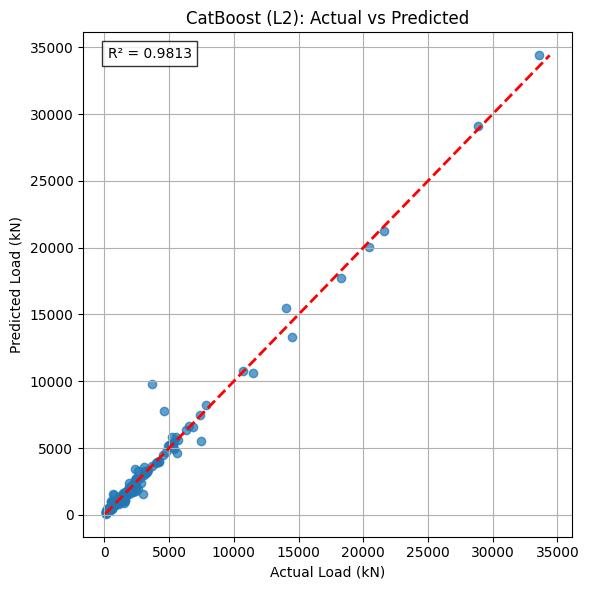

In [16]:
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    iterations=1200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

cat_model.fit(x_train_scaled, y_train)

# Prediction
y_cat_train = cat_model.predict(x_train_scaled)
y_cat_pred = cat_model.predict(x_test_scaled)

# Evaluation
cat_results = pd.DataFrame({
    "Model": ["CatBoost (L2) Testing Data"],
    "R2 Score": [round(r2_score(y_test, y_cat_pred),4)],
    "RMSE": [round(root_mean_squared_error(y_test, y_cat_pred),3)],
    "MAE": [round(mean_absolute_error(y_test, y_cat_pred),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_test, y_cat_pred)*100,2)]
})
print(cat_results.to_string(index=False))

cat_res_train = pd.DataFrame({
    "Model": ["CatBoost (L2 Training Data)"],
    "R2 Score": [round(r2_score(y_train, y_cat_train),4)],
    "RMSE": [round(root_mean_squared_error(y_train, y_cat_train),3)],
    "MAE": [round(mean_absolute_error(y_train, y_cat_train),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_train, y_cat_train)*100,2)]
})
print(cat_res_train.to_string(index=False))

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_cat_pred, alpha=0.7)

min_val = min(y_test.min(), y_cat_pred.min())
max_val = max(y_test.max(), y_cat_pred.max())

plt.plot([min_val,max_val],[min_val,max_val],'r--',linewidth=2)

plt.xlabel("Actual Load (kN)")
plt.ylabel("Predicted Load (kN)")
plt.title("CatBoost (L2): Actual vs Predicted")

plt.text(
    0.05,0.95,
    f"R² = {r2_score(y_test,y_cat_pred):.4f}",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white",alpha=0.8)
)

plt.grid(True)
plt.tight_layout()
plt.show()


## Creating an ANN Model

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [18]:
# train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

# Standardization of data
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


# creating Tensor array
x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

print(type(y_train))
print(type(x_train_scaled))
print(type(x_train_tensor))


# Creating Tensor dataset
train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)

# Creating dataset loader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

<class 'pandas.Series'>
<class 'numpy.ndarray'>
<class 'torch.Tensor'>


In [19]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            # 1st hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)
    

model=ANN()

# loss, optimizer
criterion=nn.MSELoss()
optimizer= optim.Adam(model.parameters())




In [20]:
# Training the ANN model

train_losses=[]
val_losses=[]
best_val_loss=float("inf")

epochs=100

for epoch in range(epochs):

    model.train()
    running_loss=0.0    # total training loss for 1 epoch

    for xb,yb in train_loader:      # xb & yb are features and lebels of 1 batch
        optimizer.zero_grad() 

        outputs=model(xb)       # forward prop. -> predict the output for this batch
        loss=criterion(outputs,yb)      # compute loss
        loss.backward()     # back prop. -> compute the gradients
        optimizer.step()    # params update

        running_loss+=loss.item()   # .item is used to convert the tensor value to float value as loss is tensor value
    
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():   # torch auto update gradients so we need to tell that we don't want to compute the gradient
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=criterion(outputs,yb)
            running_val_loss+=loss

    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")      # for storing the model we use .pt ot .pth file extention


epoch 1/100 ==> train loss = 33172712.55172414 & val loss = 19448090.0
epoch 2/100 ==> train loss = 33122737.73275862 & val loss = 19447300.0
epoch 3/100 ==> train loss = 33149194.939655174 & val loss = 19446426.0
epoch 4/100 ==> train loss = 35461784.077586204 & val loss = 19445380.0
epoch 5/100 ==> train loss = 33127553.844827585 & val loss = 19443782.0
epoch 6/100 ==> train loss = 33071756.452586208 & val loss = 19441762.0
epoch 7/100 ==> train loss = 35853680.62068965 & val loss = 19439042.0
epoch 8/100 ==> train loss = 33130590.80172414 & val loss = 19435630.0
epoch 9/100 ==> train loss = 33134255.474137932 & val loss = 19431690.0
epoch 10/100 ==> train loss = 33113481.077586208 & val loss = 19427116.0
epoch 11/100 ==> train loss = 34130307.38362069 & val loss = 19421772.0
epoch 12/100 ==> train loss = 33174842.577586208 & val loss = 19414670.0
epoch 13/100 ==> train loss = 33124818.54310345 & val loss = 19406700.0
epoch 14/100 ==> train loss = 33072382.353448275 & val loss = 1939

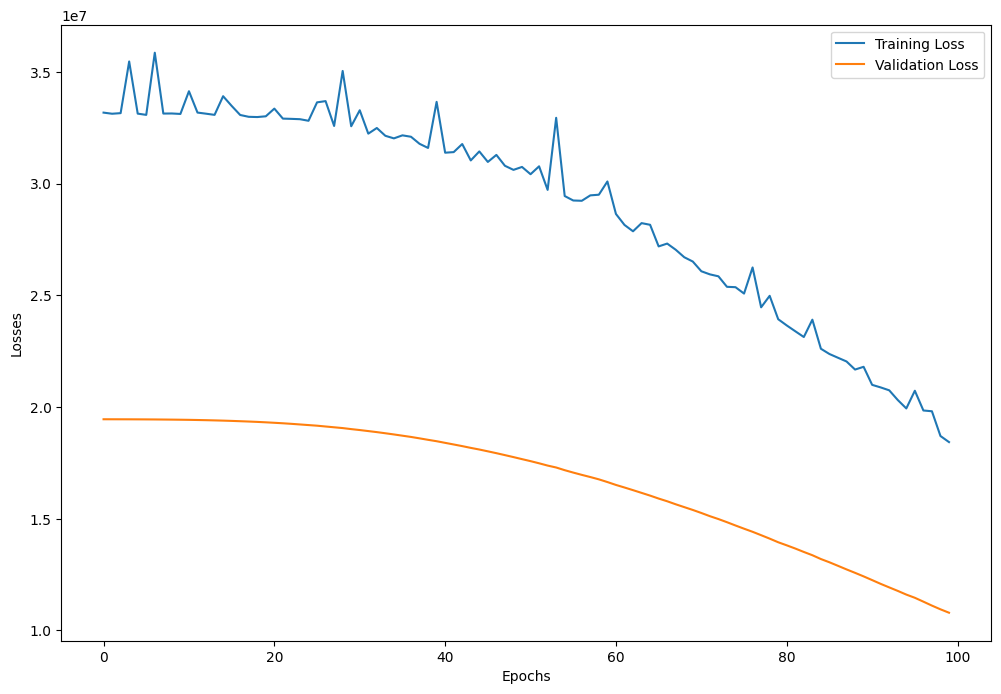

In [21]:
# Plot of losses
import matplotlib.pyplot as plt 

loss_df=pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"],label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [22]:
# Saving and loading the best model
model.load_state_dict(torch.load("best_model.pt"))


# Evaluation of the Model
model.eval()
with torch.no_grad():
    train_preds=model(x_train_tensor)
    test_preds=model(x_test_tensor)

    train_mse_loss=criterion(y_train_tensor,train_preds)
    test_mse_loss=criterion(y_test_tensor,test_preds)

print(f"Training MSE: {train_mse_loss}")
print(f"Testing MSE: {test_mse_loss}")

# r2_score
from sklearn.metrics import r2_score
print(f"R2 score for training: {r2_score(y_train,train_preds)}")
print(f"R2 score for testing: {r2_score(y_test,test_preds)}")


# Comparison of data 
predicted_df=pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df], axis=1)

Training MSE: 18577824.0
Testing MSE: 11979907.0
R2 score for training: 0.30191482036404527
R2 score for testing: 0.26236486394403


,Predicted Values,Actual Values
0,1270.132080,2340.000000
1,358.051575,686.210000
2,378.352997,575.650355
3,510.465729,550.000000
4,579.852295,4040.339800
...,...,...
224,167.562134,328.718908
225,404.948364,2112.905267
226,75.205788,353.000000
227,134.052567,644.296905


Using device: mps

Original data split:
Training: (912, 13)
Testing : (229, 13)

ANN data split:
Training   : (775, 13)
Validation : (137, 13)
Final Test : (229, 13)



ANN Architecture:
ANN(
  (model): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): SiLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): SiLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Training ANN...

Epoch    1/5000 | Train Loss = 0.482286 | Val Loss = 0.041327 | LR = 1.00e-03
Epoch  100/5000 | Train Loss = 0.022166 | Val Loss = 0.015377 | LR = 1.00e-03
Epoch  200/5000 | Train Loss = 0.007727 | Val Loss = 0.014040 | LR = 5.00e-04
Epoch  300/5000 | Train Loss = 0.004537 | Val Loss = 0.020256 | LR = 2.50e-04
Epoch  400/5000 | Train Loss = 0.003789 | Val Loss = 0.022237 | LR = 1.25e-04

Early stopping at epoch 419

Best Validation Loss: 0.010217348113656044

OPTIMIZED ANN RESULTS
   Dataset     R2         MSE     RMSE      MAE  MAPE (%)
  Training 0.9866 

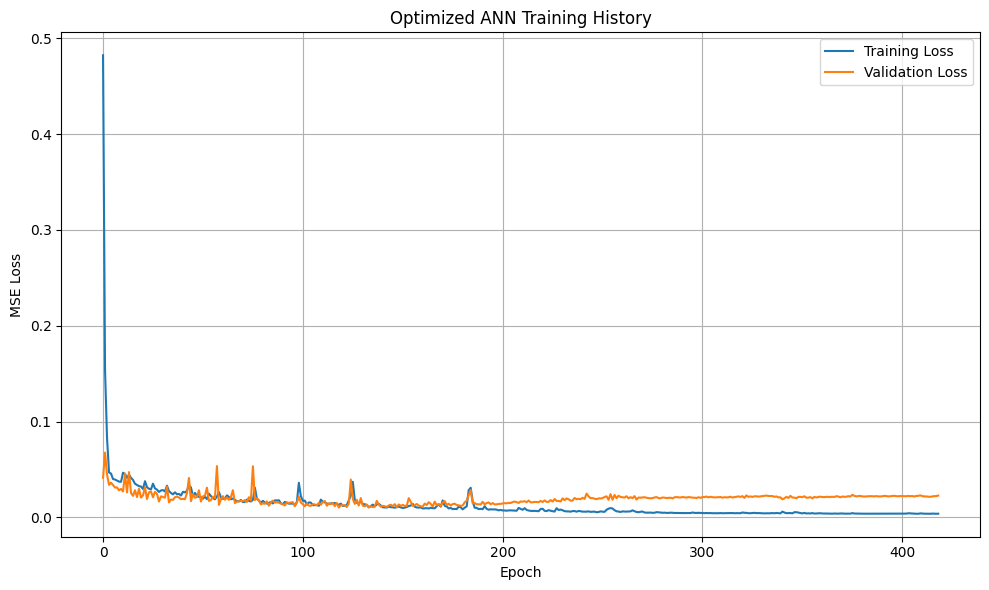

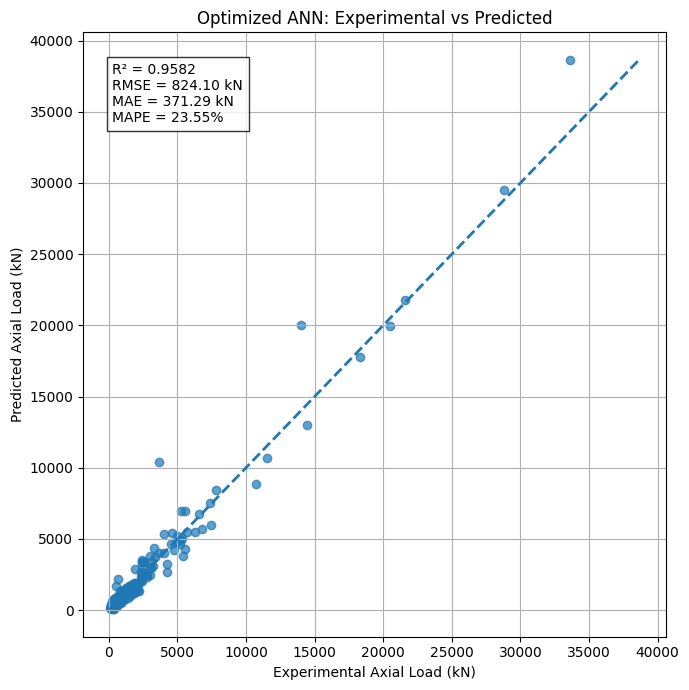

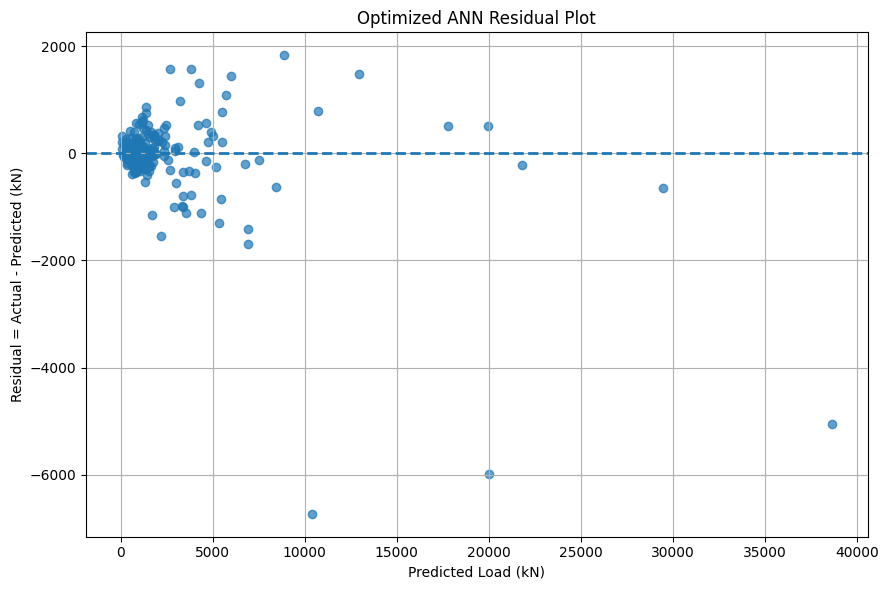


Actual vs Predicted:
    Actual Values  Predicted Values  Residual
0        2340.000       2381.409912   -41.410
1         686.210        908.622986  -222.413
2         575.650        598.271973   -22.621
3         550.000       1695.360962 -1145.361
4        4040.340       5333.189941 -1292.850
5        1325.570       1413.103027   -87.533
6        1314.091       1543.109985  -229.019
7        7432.978       5984.532227  1448.447
8        1067.000       1058.213013     8.787
9        1372.931       1306.427979    66.503
10       4519.000       4654.961914  -135.962
11       1112.055       1284.844971  -172.790
12        540.950        618.179016   -77.229
13       5714.000       5508.308105   205.692
14       6538.000       6743.778809  -205.779
15       1167.300       1149.709961    17.590
16       2386.000       3361.266113  -975.267
17       1085.000       1172.505981   -87.506
18        244.000        351.834015  -107.834
19        825.720        726.502991    99.217

Model saved

In [23]:
import random
import copy
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("\nOriginal data split:")
print("Training:", x_train.shape)
print("Testing :", x_test.shape)
x_ann_train, x_val, y_ann_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.15,
    random_state=42
)
print("\nANN data split:")
print("Training   :", x_ann_train.shape)
print("Validation :", x_val.shape)
print("Final Test :", x_test.shape)
x_scaler = StandardScaler()
x_ann_train_scaled = x_scaler.fit_transform(
    x_ann_train
)
x_val_scaled = x_scaler.transform(
    x_val
)
x_test_scaled = x_scaler.transform(
    x_test
)
x_full_train_scaled = x_scaler.transform(
    x_train
)
y_scaler = StandardScaler()
y_ann_train_scaled = y_scaler.fit_transform(
    np.asarray(
        y_ann_train
    ).reshape(-1, 1)
)
y_val_scaled = y_scaler.transform(
    np.asarray(
        y_val
    ).reshape(-1, 1)
)
x_train_tensor = torch.tensor(
    x_ann_train_scaled,
    dtype=torch.float32
)
y_train_tensor = torch.tensor(
    y_ann_train_scaled,
    dtype=torch.float32
)
x_val_tensor = torch.tensor(
    x_val_scaled,
    dtype=torch.float32
)
y_val_tensor = torch.tensor(
    y_val_scaled,
    dtype=torch.float32
)
x_test_tensor = torch.tensor(
    x_test_scaled,
    dtype=torch.float32
)
x_full_train_tensor = torch.tensor(
    x_full_train_scaled,
    dtype=torch.float32
)
train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor
)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


class ANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(
                input_dim,
                128
            ),
            nn.SiLU(),
            nn.Linear(
                128,
                128
            ),
            nn.SiLU(),
            nn.Linear(
                128,
                64
            ),
            nn.SiLU(),
            nn.Linear(
                64,
                32
            ),
            nn.SiLU(),
            nn.Linear(
                32,
                1
            )
        )
        self.apply(
            self._initialize_weights
        )
    def _initialize_weights(self, layer):
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(
                layer.weight
            )
            if layer.bias is not None:
                nn.init.zeros_(
                    layer.bias
                )
    def forward(self, x):
        return self.model(x)
input_dim = x_ann_train.shape[1]
model = ANN(
    input_dim
).to(device)
print("\nANN Architecture:")
print(model)
criterion = nn.MSELoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=75,
    min_lr=1e-6
)
EPOCHS = 5000
EARLY_STOPPING_PATIENCE = 300
best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0
train_losses = []
val_losses = []
x_val_device = x_val_tensor.to(device)
y_val_device = y_val_tensor.to(device)
print("\nTraining ANN...\n")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_train_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(
            outputs,
            yb
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )
        optimizer.step()
        running_train_loss += (
            loss.item()
            *
            xb.size(0)
        )
    epoch_train_loss = (
        running_train_loss
        /
        len(train_loader.dataset)
    )
    train_losses.append(
        epoch_train_loss
    )
    model.eval()
    with torch.no_grad():
        val_outputs = model(
            x_val_device
        )
        epoch_val_loss = criterion(
            val_outputs,
            y_val_device
        ).item()
    val_losses.append(
        epoch_val_loss
    )
    scheduler.step(
        epoch_val_loss
    )
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = copy.deepcopy(
            model.state_dict()
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    if epoch == 1 or epoch % 100 == 0:
        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )
        print(
            f"Epoch {epoch:4d}/{EPOCHS} | "
            f"Train Loss = {epoch_train_loss:.6f} | "
            f"Val Loss = {epoch_val_loss:.6f} | "
            f"LR = {current_lr:.2e}"
        )
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch}"
        )
        break
model.load_state_dict(
    best_model_state
)
model = model.to(device)
print(
    "\nBest Validation Loss:",
    best_val_loss
)
model.eval()
with torch.no_grad():
    train_preds_scaled = model(
        x_full_train_tensor.to(device)
    ).cpu().numpy()
    val_preds_scaled = model(
        x_val_tensor.to(device)
    ).cpu().numpy()
    test_preds_scaled = model(
        x_test_tensor.to(device)
    ).cpu().numpy()
train_preds = y_scaler.inverse_transform(
    train_preds_scaled
).ravel()
val_preds = y_scaler.inverse_transform(
    val_preds_scaled
).ravel()
test_preds = y_scaler.inverse_transform(
    test_preds_scaled
).ravel()


def calculate_metrics(
    actual,
    predicted
):
    r2 = r2_score(actual,predicted)
    mse = mean_squared_error(
        actual,
        predicted
    )
    rmse = np.sqrt(
        mse
    )
    mae = mean_absolute_error(
        actual,
        predicted
    )
    mape = (
        mean_absolute_percentage_error(actual,predicted)*100
    )
    return (
        r2,
        mse,
        rmse,
        mae,
        mape
    )
train_r2, \
train_mse, \
train_rmse, \
train_mae, \
train_mape = calculate_metrics(
    y_train,
    train_preds
)
val_r2, \
val_mse, \
val_rmse, \
val_mae, \
val_mape = calculate_metrics(
    y_val,
    val_preds
)
test_r2, \
test_mse, \
test_rmse, \
test_mae, \
test_mape = calculate_metrics(
    y_test,
    test_preds
)
results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Testing"
    ],
    "R2": [
        train_r2,
        val_r2,
        test_r2
    ],
    "MSE": [
        train_mse,
        val_mse,
        test_mse
    ],
    "RMSE": [
        train_rmse,
        val_rmse,
        test_rmse
    ],
    "MAE": [
        train_mae,
        val_mae,
        test_mae
    ],
    "MAPE (%)": [
        train_mape,
        val_mape,
        test_mape
    ]
})
print("\n" + "=" * 80)
print("OPTIMIZED ANN RESULTS")
print("=" * 80)
print(
    results
    .round(4)
    .to_string(
        index=False
    )
)
print("\n" + "=" * 80)
print("FINAL ANN SUMMARY")
print("=" * 80)
print(
    f"ANN TRAINING R²   : "
    f"{train_r2:.4f}"
)
print(
    f"ANN VALIDATION R² : "
    f"{val_r2:.4f}"
)
print(
    f"ANN TESTING R²    : "
    f"{test_r2:.4f}"
)
print(
    f"ANN TEST RMSE     : "
    f"{test_rmse:.4f} kN"
)
print(
    f"ANN TEST MAE      : "
    f"{test_mae:.4f} kN"
)
print(
    f"ANN TEST MAPE     : "
    f"{test_mape:.4f}%"
)
print("=" * 80)
plt.figure(
    figsize=(10, 6)
)
plt.plot(
    train_losses,
    label="Training Loss"
)
plt.plot(
    val_losses,
    label="Validation Loss"
)
plt.xlabel(
    "Epoch"
)
plt.ylabel(
    "MSE Loss"
)
plt.title(
    "Optimized ANN Training History"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.figure(
    figsize=(7, 7)
)
plt.scatter(
    y_test,
    test_preds,
    alpha=0.7
)
minimum = min(
    np.min(y_test),
    np.min(test_preds)
)
maximum = max(
    np.max(y_test),
    np.max(test_preds)
)
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    linewidth=2
)
plt.xlabel(
    "Experimental Axial Load (kN)"
)
plt.ylabel(
    "Predicted Axial Load (kN)"
)
plt.title(
    "Optimized ANN: Experimental vs Predicted"
)
plt.text(
    0.05,
    0.95,
    (
        f"R² = {test_r2:.4f}\n"
        f"RMSE = {test_rmse:.2f} kN\n"
        f"MAE = {test_mae:.2f} kN\n"
        f"MAPE = {test_mape:.2f}%"
    ),
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(
        facecolor="white",
        alpha=0.8
    )
)
plt.grid(True)
plt.tight_layout()
plt.show()
residuals = (
    np.asarray(y_test)
    -
    test_preds
)
plt.figure(
    figsize=(9, 6)
)
plt.scatter(
    test_preds,
    residuals,
    alpha=0.7
)
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)
plt.xlabel(
    "Predicted Load (kN)"
)
plt.ylabel(
    "Residual = Actual - Predicted (kN)"
)
plt.title(
    "Optimized ANN Residual Plot"
)
plt.grid(True)
plt.tight_layout()
plt.show()
comparison_df = pd.DataFrame({
    "Actual Values":
        np.asarray(
            y_test
        ),
    "Predicted Values":
        test_preds,
    "Residual":
        np.asarray(
            y_test
        )
        -
        test_preds
})
print("\nActual vs Predicted:")
print(
    comparison_df
    .round(3)
    .head(20)
)
torch.save(
    model.state_dict(),
    "optimized_ann_model.pt"
)
print(
    "\nModel saved as: optimized_ann_model.pt"
)